# HW 1 Guide B: The CRSP Market Index

The CRSP (Center for Research in Security Prices) dataset provides two indices
for market returns: an equal-weighted index and a value-weighted index (both provided
in terms of returns with and without dividends). The equal-weighted index
computes the simple average of returns across stocks. This series is available as `EWRETD` and `EWRETX`, (with and without dividends, respectively).
The value-Weighted Returns index represents a stock market index that calculates the return on investment by considering both the price changes and dividends of each component security, weighted by its market capitalization. This means that larger companies have a greater impact on the index's performance compared to smaller companies. The value-weighting approach aims to reflect the actual investment returns that an investor would achieve by holding a market portfolio, mirroring the performance of the overall market or specific market segments more accurately than equal-weighted indices. The CRSP indices are widely used in academic research and financial analysis to study market trends, evaluate investment strategies, and benchmark the performance of portfolios against the broader market. This series is available in the CRSP tables under the mnemonic `VWRETD` and `VWRETX` (with and without dividends, respectively).

In this guide, we'll discuss the construction of the equal- and value-weighted market return indices. To construct these indices, we'll follow the suggestions here: https://wrds-www.wharton.upenn.edu/pages/support/support-articles/crsp/index-and-deciles/constructing-value-weighted-return-series-matches-vwretd-crsp-monthly-value-weighted-returns-includes-distributions/

These suggestions boil down to the most important part: we must select the correct universe of stocks that comprise "the market".

The code that builds the indices lives in `src/calc_CRSP_indices.py`, and
the `doit` task `calc_CRSP_indices` runs it and saves the result. This guide
loads that result, explains the choices behind it, and compares it with
CRSP's own series.

In [1]:
import calc_CRSP_indices
import figures
import misc_tools
import pandas as pd
import pull_CRSP_stock
from settings import config

DATA_DIR = config("DATA_DIR")

## Inclusion into the CRSP Market Index:

From  https://wrds-www.wharton.upenn.edu/pages/support/support-articles/crsp/index-and-deciles/constructing-value-weighted-return-series-matches-vwretd-crsp-monthly-value-weighted-returns-includes-distributions/ ,


> Our experiments with different VWRETD replication methods show that it is relatively easy to come close to this data series using PERMNO-based returns in the CRSP datasets, but exact matches to every data month is not possible because we do not know the exact sample set of PERMNOs used by CRSP.  Their criteria is listed in the CRSP manual and is roughly:
>
> **CRSP CAP-BASED PORTFOLIOS** -- The following types of securities, listed on NYSE, AMEX, and Nasdaq National Market, are eligible for inclusion in the Cap-Based Indices:
>
> - Common Stocks
> - Certificates
> - Shares of Beneficial Interest
> - Units (Depository Units, Units of Beneficial Interest, Units of Limited Partnership Interest, Depository Receipts, etc.)
>
> The following types of securities are NOT eligible for inclusion in the Cap-Based Indices:
>
> - ADRs
> - Closed-End Mutual Funds, WEBS Index Funds, Unit Investment Trusts
> - All Common Stocks with non-US Incorporation
> - Americus Trust Components
> - HOLDRs Trusts
> - REITs (Real Estate Investment Trusts)
> - Rights and Warrants
> - Preferred stock
> - "Packaged" Units (Common Stocks Bundled with Rights or Warrants)
> - Over-the-Counter Bulletin Board Issues
> - N.B. The Cap-Based Indices do include returns from time ranges during which eligible securities trade on "leading prices" or "reorganization" when-issued status. The Cap-Based Indices do NOT include returns from time ranges during which eligible securities trade on "ex-distribution" or "additional" when-issued status.
>
> Note that VWRETD is not computed by WRDS but provided directly by CRSP along with the PERMNO based returns. For general SAS coding help for this problem see the WRDS Research Application: Portfolios by Size and Book-to-Market. This WRDS Support document provides examples of cap-based decile breakdowns, but the same general principles apply to the total market index.

In the legacy (SIZ) version of CRSP, this universe was usually expressed
with share codes, as in this query:
```
    SELECT
        date,
        msf.permno, msf.permco, shrcd, exchcd, comnam, shrcls,
        ret, retx, dlret, dlretx, dlstcd,
        prc, altprc, vol, shrout, cfacshr, cfacpr,
        naics, siccd
    FROM crspm.msf AS msf
    LEFT JOIN
        crspm.msenames as msenames
    ON
        msf.permno = msenames.permno AND
        msenames.namedt <= msf.date AND
        msf.date <= msenames.nameendt
    LEFT JOIN
        crspm.msedelist as msedelist
    ON
        msf.permno = msedelist.permno AND
        date_trunc('month', msf.date)::date =
        date_trunc('month', msedelist.dlstdt)::date
    WHERE
        msf.date BETWEEN '{start_date}' AND '{end_date}' AND
        msenames.shrcd IN (10, 11, 20, 21, 40, 41, 70, 71, 73)
```
To best understand this, please look up `shrcd` in the Data Manual here: https://wrds-www.wharton.upenn.edu/documents/396/CRSP_US_Stock_Indices_Data_Descriptions.pdf . You'll find the information on p. 81.

CRSP has since moved to the CIZ format, which `pull_CRSP_stock.pull_CRSP_monthly_file`
uses. Share codes are gone. Their two digits are split into separate fields:

- `securitytype` and `securitysubtype`: equity (`EQTY`) and common stock (`COM`)
  versus preferred stock, warrants, and so on.
- `sharetype`: `NS` for an ordinary share, `AD` for an ADR, and other codes
  for special share types.
- `issuertype`: `CORP` and `ACOR` for corporations, `REIT` for real estate
  investment trusts.
- `usincflg`: `Y` if the issuer is incorporated in the US.
- `primaryexch`: the primary exchange (`N` NYSE, `A` AMEX, `Q` Nasdaq).

The pull keeps every equity security (`securitytype = 'EQTY'`), which is
roughly the universe of CRSP's own index. Counting the values of these fields
in the pulled file shows what is in that universe:

In [2]:
df_msf = pull_CRSP_stock.load_CRSP_monthly_file(data_dir=DATA_DIR)
df_msf[["sharetype", "issuertype", "usincflg"]].value_counts().head(10)

sharetype  issuertype  usincflg
NS         CORP        Y           2775891
           ACOR        Y            661277
           CORP        N            241208
AD         CORP        N            149043
NS         REIT        Y             69397
UG         CORP        Y             41832
SB         REIT        Y             35195
AD         ACOR        N             19028
UG         CORP        N              3633
SB         CORP        Y              3169
Name: count, dtype: int64

## Calculation of Equal-Weighted Returns and Value-Weighted Returns

With the proper universe of stocks in hand, all that is left is to group the returns by `permno` (the identifier of choice here) and average. However, the equal weighted average is a mere simple average. To calculate the value-weighted average, we need to calculate the *lagged* market cap of each stock $i$ at time $t$.

That is, the value-weighted return is given by the following formula:

$$
r_t = \frac{\sum_{i=1}^{N_t} w_{i,t-1} \, r_{i,t}}{\sum_{i=1}^{N_t} w_{i,t-1}}
$$

where $w_{i,t-1}$ is the market capitalization of stock $i$ at time $t-1$ and
$r_t$ can be the returns with dividends `ret` or the returns without dividends `retx`.
The market capitalization of a stock is its price times the shares outstanding,

$$
w_{it} = \text{SHROUT}_{it} \times \text{PRC}_{it}.
$$

## Lagging market cap correctly

Note, a helpful tool to create the lagged time series for market capitalization is provided in `misc_tools`.
Use the function `with_lagged_column`, which will create a lagged column that accounts for the fact that multiple stocks show up in a flat file. See the following example:

In [3]:
a = [
    [1, "1990/1/1", 1],
    [1, "1990/2/1", 2],
    [1, "1990/3/1", 3],
    [2, "1989/12/1", 3],
    [2, "1990/1/1", 3],
    [2, "1990/2/1", 4],
    [2, "1990/3/1", 5.5],
    [2, "1990/4/1", 5],
    [2, "1990/6/1", 6],
]
data = pd.DataFrame(a, columns=["id", "date", "value"])
data["date"] = pd.to_datetime(data["date"])
data

,id,date,value
0,1,1990-01-01,1.0
1,1,1990-02-01,2.0
2,1,1990-03-01,3.0
3,2,1989-12-01,3.0
4,2,1990-01-01,3.0
5,2,1990-02-01,4.0
6,2,1990-03-01,5.5
7,2,1990-04-01,5.0
8,2,1990-06-01,6.0


In [4]:
data_lag = misc_tools.with_lagged_columns(
    df=data, column_to_lag="value", id_column="id", lags=1, freq="MS"
)
data_lag

,id,date,value,L1_value
2,1,1990-01-01,1.0,NaN
4,1,1990-02-01,2.0,1.0
6,1,1990-03-01,3.0,2.0
8,1,1990-04-01,NaN,3.0
1,2,1989-12-01,3.0,NaN
3,2,1990-01-01,3.0,3.0
5,2,1990-02-01,4.0,3.0
7,2,1990-03-01,5.5,4.0
9,2,1990-04-01,5.0,5.5
11,2,1990-05-01,NaN,5.0


As you can see, naively using `shift` to create our lag would miss the fact that observation `1989-12-01` for stock `id=2` should have a missing lagged `value`. For example, the following would be incorrect:


In [5]:
data["value"].shift(1)

0    NaN
1    1.0
2    2.0
3    3.0
4    3.0
5    3.0
6    4.0
7    5.5
8    5.0
Name: value, dtype: float64

## How close the manual indices come

The CRSP index file (`msix`) carries CRSP's own series: `vwretd` and
`ewretd` (with dividends) and `vwretx` and `ewretx` (without). The
`calc_CRSP_indices` task saves them side by side with the manual versions,
which end in `_manual`.

In [6]:
df_idxs = calc_CRSP_indices.load_CRSP_indices_manual(data_dir=DATA_DIR)
manual_vs_crsp = [
    "vwretd",
    "vwretd_manual",
    "vwretx",
    "vwretx_manual",
    "ewretd",
    "ewretd_manual",
    "ewretx",
    "ewretx_manual",
]
df_idxs[manual_vs_crsp].corr().round(4)

,vwretd,vwretd_manual,vwretx,vwretx_manual,ewretd,ewretd_manual,ewretx,ewretx_manual
vwretd,1.0000,0.9996,0.9995,0.9990,0.8592,0.8572,0.8593,0.8572
vwretd_manual,0.9996,1.0000,0.9991,0.9995,0.8602,0.8583,0.8602,0.8583
vwretx,0.9995,0.9991,1.0000,0.9996,0.8595,0.8575,0.8597,0.8578
vwretx_manual,0.9990,0.9995,0.9996,1.0000,0.8605,0.8586,0.8608,0.8589
ewretd,0.8592,0.8602,0.8595,0.8605,1.0000,0.9991,0.9999,0.9990
ewretd_manual,0.8572,0.8583,0.8575,0.8586,0.9991,1.0000,0.9990,0.9999
ewretx,0.8593,0.8602,0.8597,0.8608,0.9999,0.9990,1.0000,0.9991
ewretx_manual,0.8572,0.8583,0.8578,0.8589,0.9990,0.9999,0.9991,1.0000


Growth of one dollar invested at the start tells the same story:

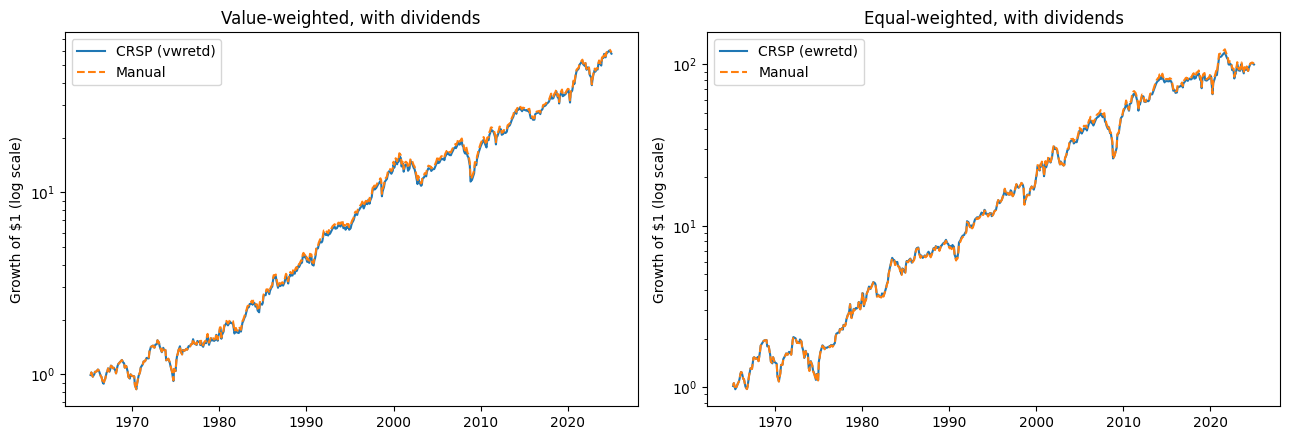

In [7]:
fig = figures.plot_CRSP_index_comparison(df_idxs)

Our manually-created return index doesn't match the CRSP index perfectly but is still very close. In this HW, you'll be required to construct this index only approximately. A loose match, as seen here, will be fine.